# Expanded multiband foundation photometry prior

This experiment expands the independent image-derived training sample and predicts morphology profile weights separately in all ten bands. Fluxes are measured jointly from native pixels with the same signed solver for each control. No catalog flux labels train the prior.

Controls: population, raw VIS pixels, raw ten-band pixels, and raw ten-band pixels plus frozen v11 stem/bottleneck features. The previous foundation prior is re-evaluated on exactly the same new simulated blends.

Model selection and precision calibration use separate guarded validation scenes. The known-flux benchmark is evaluated only after the models are frozen.

The ten-band pixel and foundation regressions use matching latent feature counts. The previous prior is a historical pipeline control.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "models/photometry").is_dir())
RUN = ROOT / "models/photometry/self_supervised/runs/q1_multiband_expanded"
BANDS = ["rubin_" + b for b in "ugrizy"] + ["euclid_" + b for b in ["VIS", "Y", "J", "H"]]
metadata = json.loads((RUN / "metadata.json").read_text())
protocol = json.loads((RUN / "injection_protocol.json").read_text())
print("Foundation:", metadata["original"]["foundation_checkpoint"])
print("Feature protocol:", metadata["feature_protocol"])
print("Benchmark:", protocol["count"], "blends; seed", protocol["seed"])


Foundation: models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt
Feature protocol: Fresh native scene; raw ten-band S/N+coverage 17x17; VIS stem 9x9; bottleneck 5x5
Benchmark: 256 blends; seed 202610020


## Independent sources and validation separation

The table counts independent bright image-fitted source profiles before noise augmentation. Rows need not refer to the same sources across bands. Whole scenes separate prior selection from precision calibration. Added-noise versions do not create additional independent galaxies.


In [2]:
print("Scenes:", metadata["scene_counts"])
print("Head feature dimensions:", metadata["head_feature_dimensions"])
display(pd.DataFrame(metadata["independent_teacher_counts"]).reindex(BANDS))
print("Noise training:", metadata["noise_training"])
print("Calibration:", metadata["calibration"])


Scenes: {'train': 300, 'tuning': 70, 'calibration': 72}
Head feature dimensions: {'vis_image': 25, 'all_images': 73, 'foundation': 73}
Noise training: ['original', 'all bands RMS x2', 'VIS RMS x4']
Calibration: Independent validation scenes; CDF residual second moments, 20% shrinkage, 3% floor


,train,tuning,calibration
rubin_u,48,8,9
rubin_g,564,147,146
rubin_r,629,165,165
rubin_i,527,138,138
rubin_z,337,93,92
rubin_y,89,17,18
euclid_VIS,580,144,144
euclid_Y,168,43,42
euclid_J,228,57,57
euclid_H,256,59,61


## Fresh paired known-flux recovery

The statistic is the median absolute fractional flux error per band, in percent. Every signed measurement is retained. The equal-band average weights bands equally. All methods share pixels, positions, PSFs and the final flux solver. The previous prior uses its original VIS-first morphology regularization.

The S/N panels show running medians; shaded bands are the 16th–84th percentile source distributions, not confidence intervals on the median.


model,legacy_foundation,population,vis_image,all_images,foundation
band,,,,,
rubin_u,15.738,17.825,17.783,17.255,16.429
rubin_g,8.236,10.066,9.828,9.550,9.534
rubin_r,7.196,8.650,8.424,8.434,8.106
rubin_i,6.508,8.170,8.067,8.182,7.955
rubin_z,7.929,9.781,9.422,9.330,9.492
rubin_y,12.681,17.210,16.845,16.118,16.108
euclid_VIS,15.544,17.357,16.260,16.793,16.711
euclid_Y,10.833,13.998,13.228,12.926,12.307
euclid_J,9.991,12.676,11.484,11.781,11.326


model
legacy_foundation    10.391
population           12.693
vis_image            12.208
all_images           12.052
foundation           11.784
Name: Equal-band average (%), dtype: float64

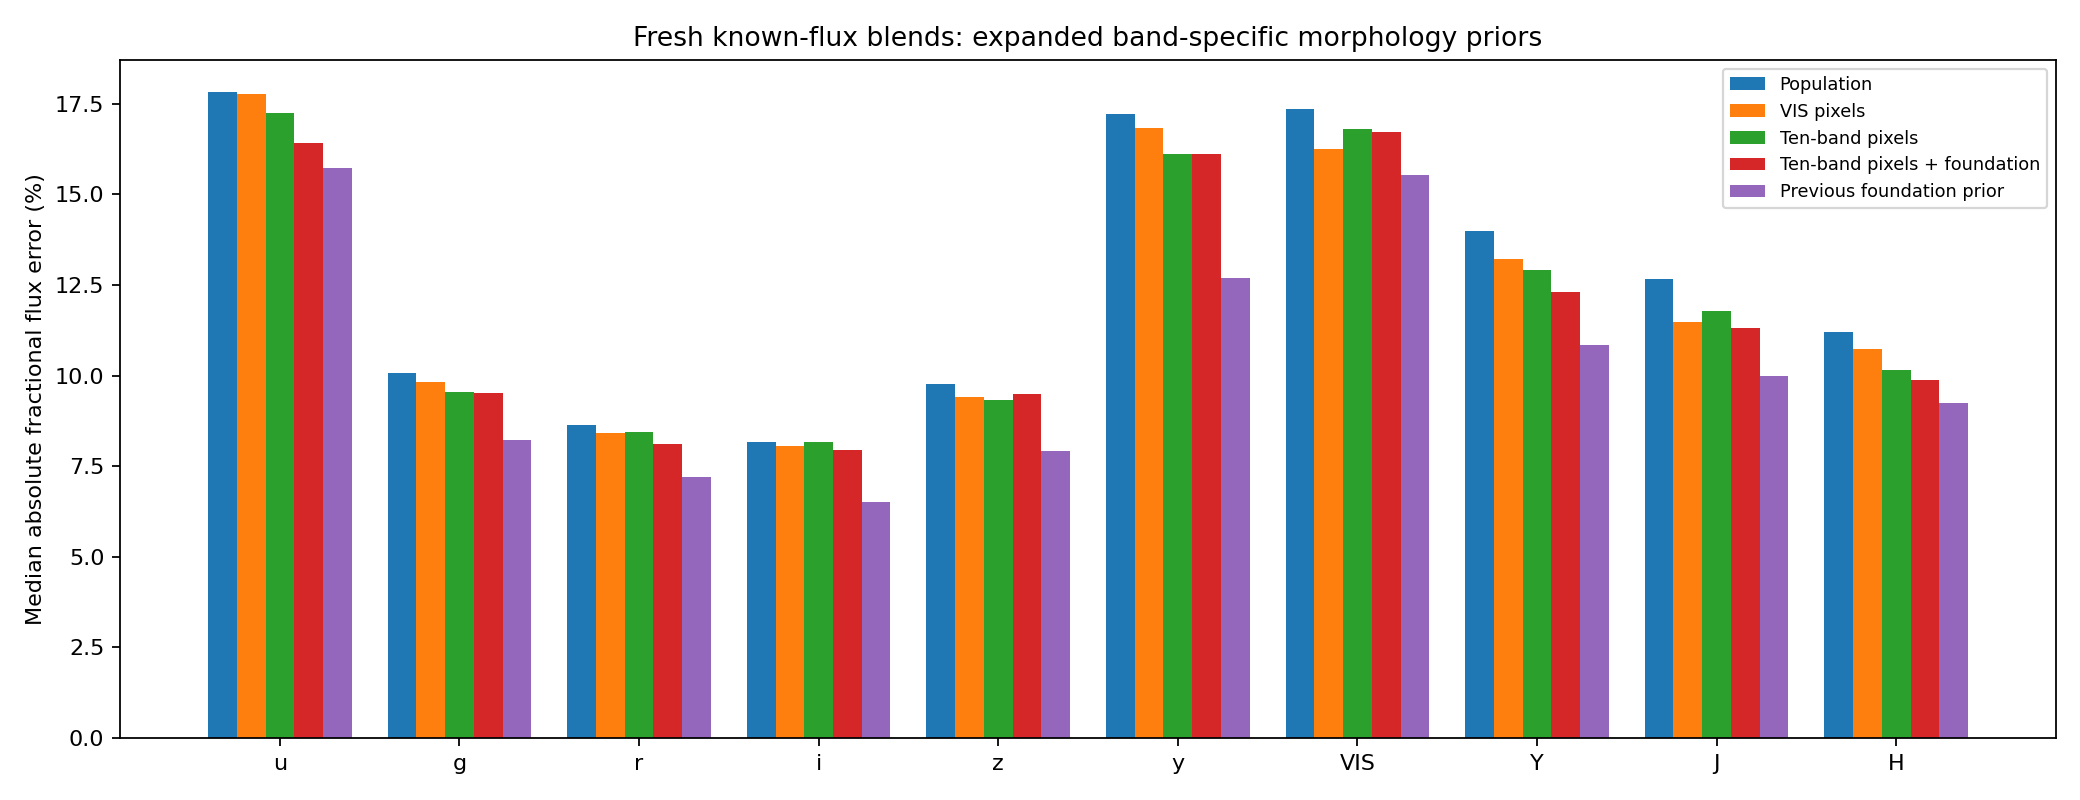

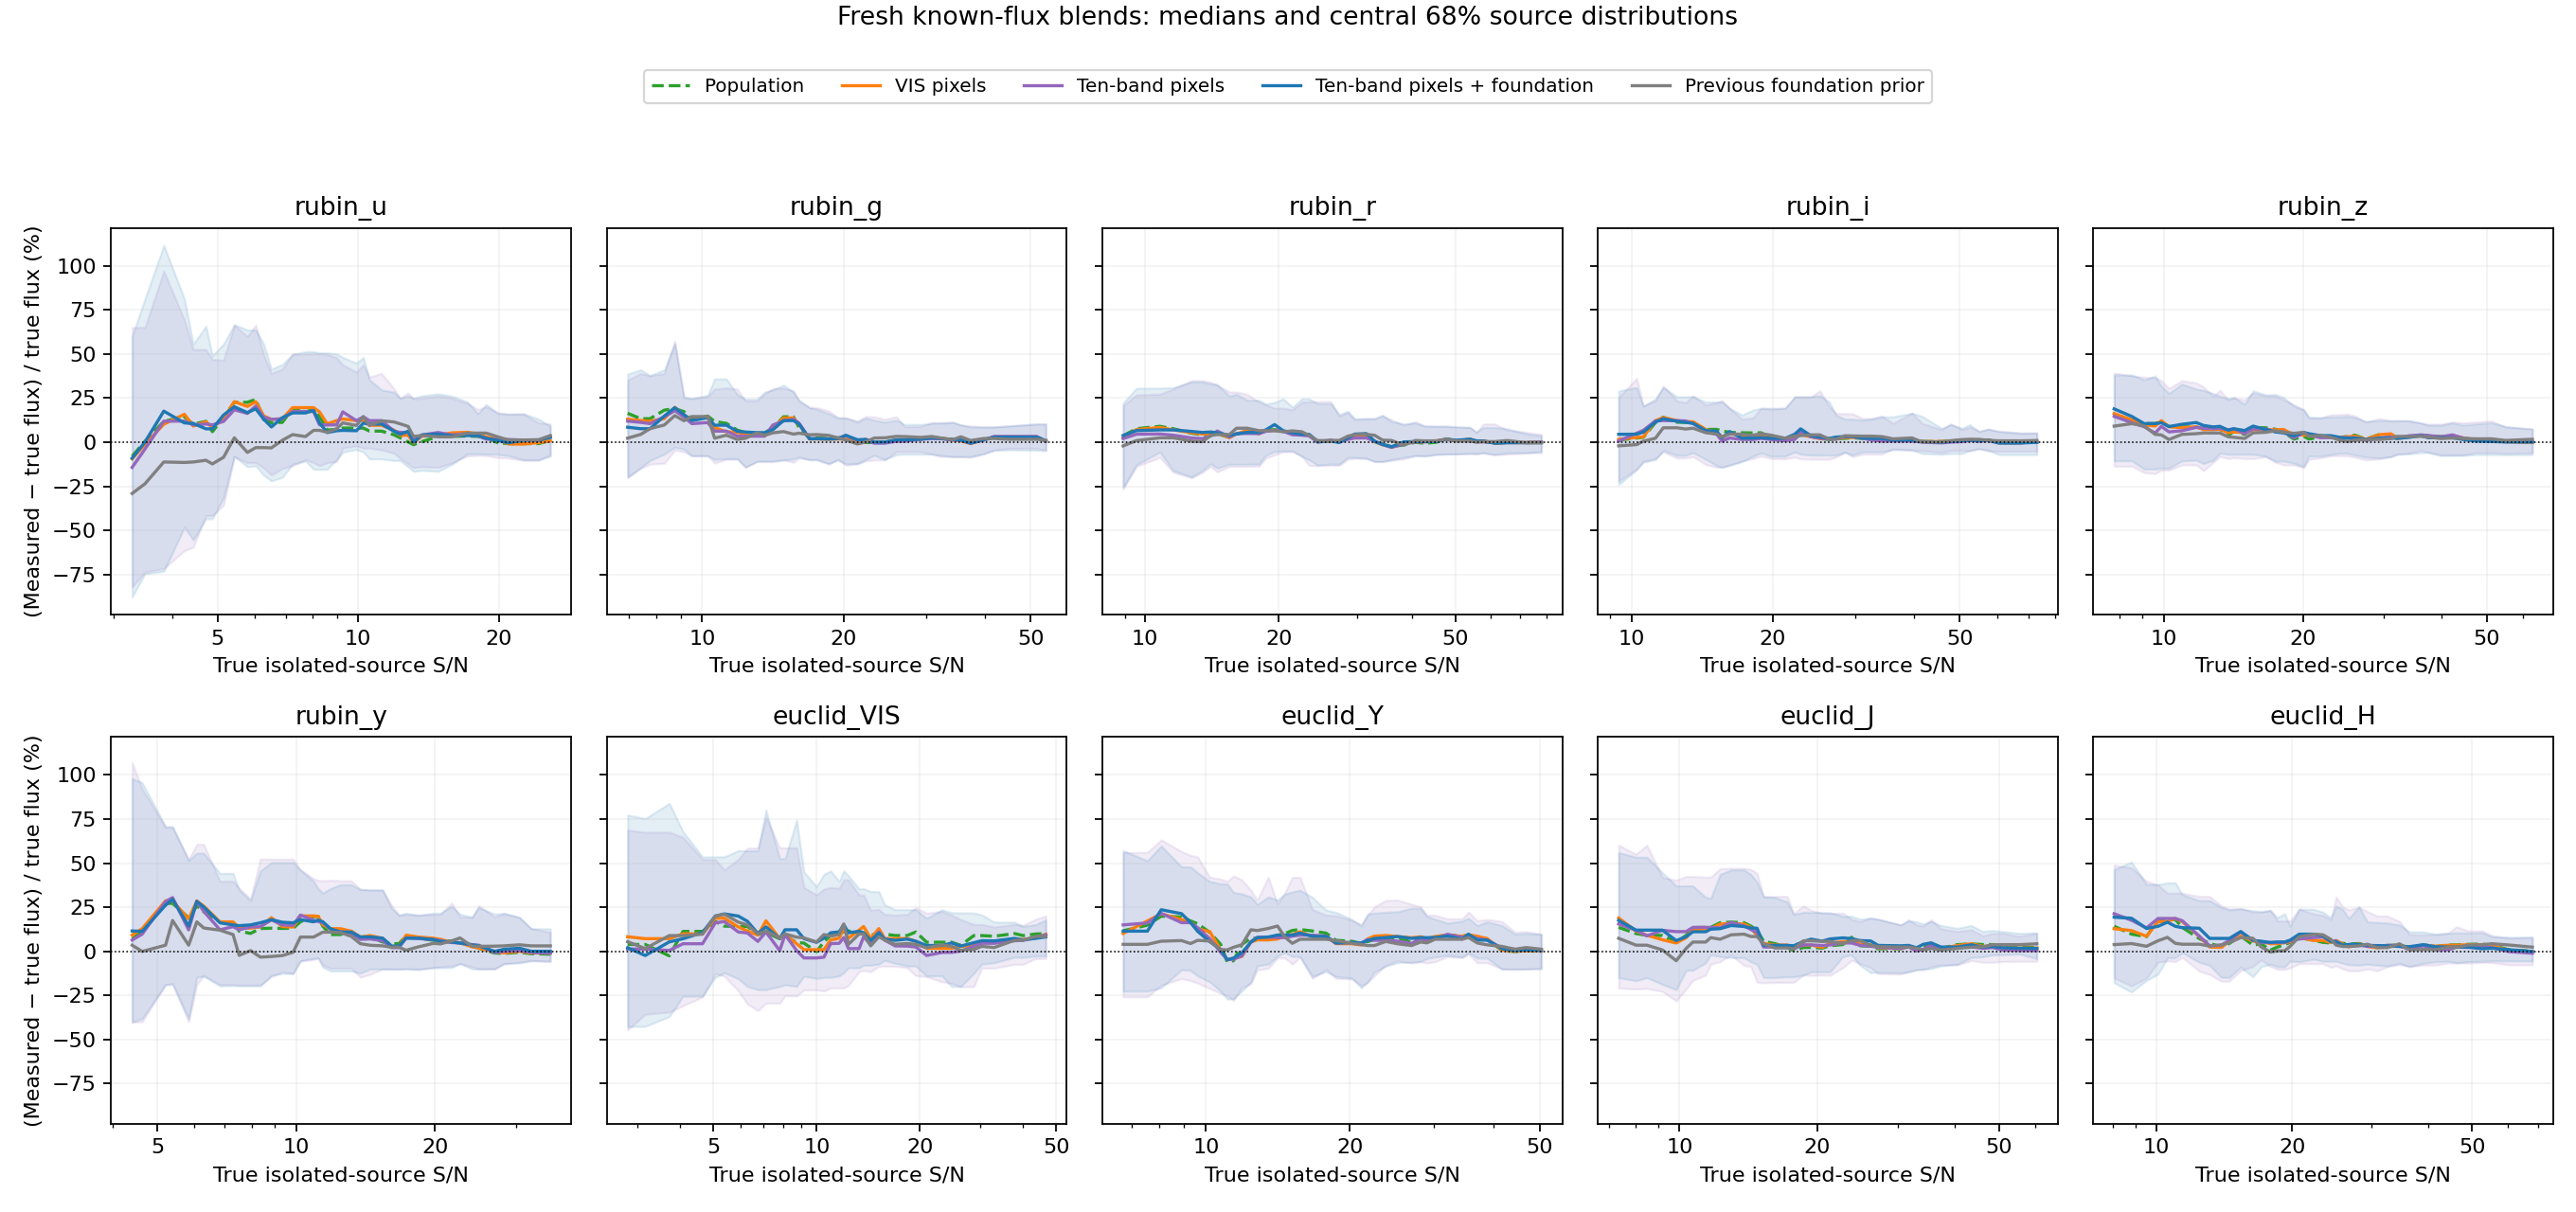

In [3]:
stats = pd.read_csv(RUN / "injection_summary.csv")
order = ["legacy_foundation", "population", "vis_image", "all_images", "foundation"]
accuracy = 100 * stats.pivot(index="band", columns="model", values="median_absolute_error").reindex(BANDS)[order]
display(accuracy.round(3))
display(accuracy.mean().rename("Equal-band average (%)").round(3))
display(Image(filename=str(RUN / "known_flux_accuracy.png")))
display(Image(filename=str(RUN / "known_flux_vs_snr.png")))


## Does the foundation add information?

Negative differences favor the new foundation prior. The strongest representation control receives the same raw ten-band pixels. Confidence intervals resample complete two-source blends, retaining all bands. They quantify this simulated sample conditional on the selected models; they omit training-set and PSF uncertainty. Intervals crossing zero are inconclusive.


In [4]:
paired = pd.read_csv(RUN / "paired_bootstrap.csv")
rows = paired[paired.band.eq("equal_band_average")].copy()
for column in ["difference", "ci_low", "ci_high"]:
    rows[column] *= 100
display(rows.set_index(["subset", "reference"])[["n_blends", "difference", "ci_low", "ci_high"]].round(3))


n_blends  difference  ci_low  ci_high
subset           reference                                               
all              vis_image               256      -0.423  -0.735   -0.093
                 all_images              256      -0.268  -0.532    0.160
                 legacy_foundation       256       1.393   0.930    1.946
                 population              256      -0.909  -1.279   -0.524
weak_VIS         vis_image               128      -0.399  -0.807    0.232
                 all_images              128       0.116  -0.358    0.745
                 legacy_foundation       128       1.888   0.996    2.738
                 population              128      -0.895  -1.279   -0.230
normal_VIS       vis_image               128      -0.745  -1.125   -0.247
                 all_images              128      -0.492  -0.795    0.040
                 legacy_foundation       128       1.112   0.497    1.847
                 population              128      -1.322  -1.642   -0.720
white_noise      vis_image               128      -0.533  -0.826   -0.117
                 all_images              128      -0.329  -0.681    0.066
                 legacy_foundation       128       1.055   0.615    1.631
                 population              128      -0.778  -1.170   -0.384
correlated_noise vis_image               128      -0.824  -1.432   -0.228
                 all_images              128      -0.247  -0.898    0.202
                 legacy_foundation       128       1.902   1.079    2.735
                 population              128      -1.215  -1.807   -0.610

## Result: retain the existing foundation head

On 256 fresh blends (512 sources), the equal-band average median absolute fractional flux error is **10.39% for the existing foundation prior**, **12.21% for expanded VIS pixels**, **12.05% for expanded ten-band pixels**, and **11.78% for the expanded foundation head**.

The new head is worse than the existing head by **+1.39 percentage points**, with a paired whole-blend bootstrap 95% interval of **+0.93 to +1.95**. Its gain over the matched-capacity ten-band pixel control is **−0.27 points (−0.53 to +0.16)**: foundation-specific improvement is inconclusive. Its gain over the VIS-only control is **−0.42 points (−0.73 to −0.09)**.

All 25,600 source/band/model measurements are present and signed fluxes are retained. Better prediction of image-fitted validation profiles did not translate into better simulated flux recovery. Expanded training coverage and a change from VIS-first coupling were tested together; the benchmark does not establish which change caused the regression. The existing foundation head remains the baseline. These heads were frozen before evaluating this test, and no test truth was used to refit them.


## Validation profile prediction

Curve-of-growth errors compare predictions with image-fitted teacher profiles. This is a morphology diagnostic, not a flux-truth test. Precision uses a separate validation-scene partition, including original, all-band-noisy, and weak-VIS inputs.


In [5]:
validation = json.loads((RUN / "prior_validation.json").read_text())
display(pd.DataFrame({mode: {band: values["calibration_error"] for band, values in bands.items()} for mode, bands in validation.items()}).reindex(BANDS).round(5))


,vis_image,all_images,foundation
rubin_u,0.02354,0.01825,0.02125
rubin_g,0.02160,0.02074,0.01853
rubin_r,0.02161,0.02053,0.01720
rubin_i,0.01822,0.01893,0.01478
rubin_z,0.01851,0.02027,0.01410
rubin_y,0.01919,0.01968,0.01840
euclid_VIS,0.01304,0.01473,0.00868
euclid_Y,0.01589,0.01944,0.01269
euclid_J,0.01386,0.01438,0.00965
euclid_H,0.01470,0.01368,0.00800


## Scope and reusable inference

The fresh test uses independently rendered exponential core/disk galaxies, color gradients, white/correlated noise, known positions, and approximate Gaussian PSFs. It does not establish calibrated real-survey flux accuracy, robustness to missing detections, uncertain astrometry, or irregular galaxies. The foundation may have seen the real held-out sky during pretraining. Flux errors remain conditional on the selected morphology and PSF.

```python
from models.photometry.self_supervised.predict import BandPriorPhotometry
photometer = BandPriorPhotometry(RUN / "priors.pt", mode="foundation")
measurement = photometer(scene)
```

Reproduce from the repository root:

```bash
OPENBLAS_NUM_THREADS=2 OMP_NUM_THREADS=2 python -m models.photometry.self_supervised.try_multiband_prior prepare
OPENBLAS_NUM_THREADS=2 OMP_NUM_THREADS=2 python -m models.photometry.self_supervised.try_multiband_prior train
OPENBLAS_NUM_THREADS=2 OMP_NUM_THREADS=2 python -m models.photometry.self_supervised.try_multiband_prior benchmark
```
